# Summary of 07_evaluation_visualization_test.ipynb
This notebook focuses on evaluating and visualizing the performance of the 6 comparative pipelines in the FYP "NLP-based AI Platform for Parliament Proceedings Analysis". It includes setup, dynamic inference testing, train vs test comparison, and visualization of key metrics (Silhouette, C_V, NPMI, Topic Diversity). The code is designed to be dynamic, with results saved as Markdown/CSV for thesis inclusion.

### Notebook Overview & Purpose

#### Objective: 
Perform inference on test split, compute intrinsic/extrinsic metrics, compare with train results from JSON, and generate tables/charts for thesis Results section.
#### Key Components: 
Dynamic extraction of train metrics from JSON, inference for test metrics, gap analysis for generalization (overfit/underfit check), and visualization (bar plots).

#### Data Sources: 
hansard_core500 train/validation/test splits, model bundles (pkl), results JSONs.

#### Output: 
Tables (train_vs_test_dynamic.md), bar charts (test_metrics_comparison_full.png), interpretation of gaps.

This aligns with FYP guideline self-check: robustness on benchmark/real-world datasets, incremental improvement across pipelines.

### Import and setup

In [3]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import pickle
from wordcloud import WordCloud
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
import umap
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from collections import Counter
from scipy.sparse import load_npz
from pymongo import MongoClient
from dotenv import load_dotenv
import re
from transformers import AutoModel, AutoTokenizer, AutoConfig
from sentence_transformers import SentenceTransformer 

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'

RESULTS_DIR = Path("results")
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)
MODEL_DIR = Path("model")

print("Loading test split and models...")

Loading test split and models...


### Load DB - test split

In [4]:
# Load Test Documents from MongoDB (hansard_core500, split_type="test")
project_root = Path.cwd().parents[0] if 'parents' in dir(Path.cwd()) else Path.cwd()
backend_env_path = project_root / "3_app_system" / "backend" / ".env"
load_dotenv(backend_env_path)

client = MongoClient(os.getenv("MONGO_URI"))
db = client["MyParliament"]

core_col = db["hansard_core500"]
seg_col = db["hansard_segmented500"]
cpatf_col = db["hansard_cpatf500"]

test_core_docs = list(core_col.find({"split_type": "test"}, {"full_text": 1, "_id": 1, "hansardDate": 1}))
test_core_texts = [doc["full_text"] for doc in test_core_docs if "full_text" in doc]


test_parent_ids = [doc["_id"] for doc in seg_col.find({"split_type": "test"}, {"_id": 1})]
print(f"Found {len(test_parent_ids)} test parent documents in hansard_segmented500")

cpatf_col = db["hansard_cpatf500"]
test_cpatf_docs = list(cpatf_col.find(
    {"parent_doc_id": {"$in": test_parent_ids}}, 
    {"cleaned_text": 1, "_id": 0}
))

test_cpatf_texts = [doc["cleaned_text"] for doc in test_cpatf_docs if doc.get("cleaned_text")]

print(f"Successfully loaded {len(test_cpatf_texts)} CPATF cleaned segments for test split")


print(f"Core test documents loaded: {len(test_core_texts)}")
print("Core sample preview:", test_core_texts[0][:200] if test_core_texts else "No data")

print(f"Cpatf test documents loaded: {len(test_cpatf_texts)}")
print("Cpatf sample preview:", test_cpatf_texts[0][:200] if test_cpatf_texts else "No data")

# P1/P2 → raw full_text from core500 (whole documents)
core_inputs = [doc.get("full_text", "") for doc in test_core_docs if doc.get("full_text")]

# P3~P6 → collect cleaned segments (correct flatten)
cpatf_inputs = []
for doc in test_cpatf_docs:
    cleaned = doc.get("cleaned_text", "")
    if isinstance(cleaned, str) and cleaned.strip():
        cpatf_inputs.append(cleaned)  # append string as one segment
    elif isinstance(cleaned, list):
        cpatf_inputs.extend([s for s in cleaned if isinstance(s, str) and s.strip()])

print(f"Core inputs (P1/P2): {len(core_inputs)} documents")
print(f"Cpatf inputs (P3~P6): {len(cpatf_inputs)} cleaned segments")
print("Cpatf sample preview:", cpatf_inputs[0][:200] if cpatf_inputs else "No data")

Found 75 test parent documents in hansard_segmented500
Successfully loaded 26754 CPATF cleaned segments for test split
Core test documents loaded: 75
Core sample preview: Volume V Tuesday No. 13 20th August, 1963

 PARLIAMENTARY
 DEBATES
 DEWAN RA‘AYAT
 (HOUSE OF REPRESENTATIVES)

 OFFICIAL REPORT

 CONTENTS
 BILL:
 Malaysia Bill (debate continued) [Col. 1335]

 EXEMPT
Cpatf test documents loaded: 26754
Cpatf sample preview: sir, i beg to second the motion. i tuan haji ahmad abdullah (kelantan hilir): tuan yang di-pertua, saya bangun memperingat kerajaan yang di-kemuka oleh menteri hal ehwal dalam negeri dan menteri ke‘ad
Core inputs (P1/P2): 75 documents
Cpatf inputs (P3~P6): 26754 cleaned segments
Cpatf sample preview: sir, i beg to second the motion. i tuan haji ahmad abdullah (kelantan hilir): tuan yang di-pertua, saya bangun memperingat kerajaan yang di-kemuka oleh menteri hal ehwal dalam negeri dan menteri ke‘ad


### Load pipeline and models

In [5]:
PIPELINES = [
    '01_tfidf_kmeans',
    '02_tfidf_lda',
    '03_mehtc_entity_only',
    '04_mehtc_xlm_zeroshot',
    '05_mehtc_lora_grpo_finetuned',
    '06_e5_large_sota'
]

models = {}
results_dict = {}
pkl_mapping = {
    '01_tfidf_kmeans': 'tfidf_kmeans_model.pkl',
    '02_tfidf_lda': 'best_lda_model.pkl',
    '03_mehtc_entity_only': 'mehtcEntity_model.pkl',
    '04_mehtc_xlm_zeroshot': 'mehtc_xlm_zeroshot_model.pkl',
    '05_mehtc_lora_grpo_finetuned': 'mehtc_lora_weighted_mlm_finetuned/mehtc_lora_mlm_best_model.pkl',
    '06_e5_large_sota': 'e5_large_sota_model_bundle.pkl'
}

for p in PIPELINES:
    json_path = RESULTS_DIR / f"pipeline{int(p.split('_')[0])}_results.json"
    if json_path.exists():
        with open(json_path, "r") as f:
            results_dict[p] = json.load(f)
    pkl_path = MODEL_DIR / pkl_mapping.get(p)
    if pkl_path.exists():
        with open(pkl_path, "rb") as f:
            models[p] = pickle.load(f)

print("Loaded models:", list(models.keys()))
print("Loaded json results:", list(results_dict.keys()))

Loaded models: ['01_tfidf_kmeans', '02_tfidf_lda', '03_mehtc_entity_only', '04_mehtc_xlm_zeroshot', '05_mehtc_lora_grpo_finetuned', '06_e5_large_sota']
Loaded json results: ['01_tfidf_kmeans', '02_tfidf_lda', '03_mehtc_entity_only', '04_mehtc_xlm_zeroshot', '05_mehtc_lora_grpo_finetuned', '06_e5_large_sota']


### Inference Testing with Full Metrics

Inference Testing with Full Metrics (Using Trained Models)



=== 01. TF-IDF + KMeans ===
Using core_inputs: 75 full documents
Silhouette: 0.0529
C_V: 0.5938
NPMI: 0.0879
Topic Diversity: 0.1175

=== 02. TF-IDF + LDA ===
Using core_inputs: 75 full documents
Processing Pipeline 2: TF-IDF + LDA (with fixed vocabulary)
Test corpus built. Number of docs: 75
Unique labels: 1
Silhouette: 0.0000
C_V: 0.4503
NPMI: -0.2227
Topic Diversity: 0.2587

=== 03. MEHTC (Entity Only) ===
Using cpatf_inputs: 26754 cleaned segments
P3 vectorizer loaded! Vocab: 22043
Silhouette: 0.0084
C_V: 0.5528
NPMI: 0.0280
Topic Diversity: 0.3500

=== 04. MEHTC + XLM-R Zero-shot ===
Using cpatf_inputs: 26754 cleaned segments
P4: Loading from bundle
Using train-time XLM-R path from bundle!
Successfully loaded embedder from bundle path!


Encoding P4 batches: 100%|██████████| 419/419 [02:56<00:00,  2.38it/s]


P4 features shape: (26754, 768)


Some weights of XLMRobertaModel were not initialized from the model checkpoint at model/mehtc_lora_weighted_mlm_finetuned/mehtc_lora_mlm_best_model/mehtc_lora_merged_model and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Merged model loaded successfully!
Total parameters: 278,043,648 (should match XLM-R base ~278M)


Encoding P5 (merged model): 100%|██████████| 419/419 [02:58<00:00,  2.35it/s]


P5 features shape: (26754, 768)
Silhouette: 0.3767
C_V: 0.4928
NPMI: 0.0801
Topic Diversity: 0.3333

=== 06. Multilingual-E5-Large (SOTA) ===
Using cpatf_inputs: 26754 cleaned segments
P6: Loading from bundle
P6: Using embedder: intfloat/multilingual-e5-large


Batches: 100%|██████████| 419/419 [02:03<00:00,  3.39it/s]


P6 features shape: (26754, 1024)
Silhouette: 0.0784
C_V: 0.5404
NPMI: 0.1130
Topic Diversity: 0.3553

Markdown Table:
| Pipeline                         |   Silhouette |    C_V |    NPMI |   Topic Diversity |
|:---------------------------------|-------------:|-------:|--------:|------------------:|
| 01. TF-IDF + KMeans              |       0.0529 | 0.5938 |  0.0879 |            0.1175 |
| 02. TF-IDF + LDA                 |       0      | 0.4503 | -0.2227 |            0.2588 |
| 03. MEHTC (Entity Only)          |       0.0084 | 0.5528 |  0.028  |            0.35   |
| 04. MEHTC + XLM-R Zero-shot      |       0.6157 | 0.3977 | -0.0459 |            0.31   |
| 05. MEHTC + LoRA Fine-tuned      |       0.3767 | 0.4928 |  0.0801 |            0.3333 |
| 06. Multilingual-E5-Large (SOTA) |       0.0784 | 0.5404 |  0.113  |            0.3553 |


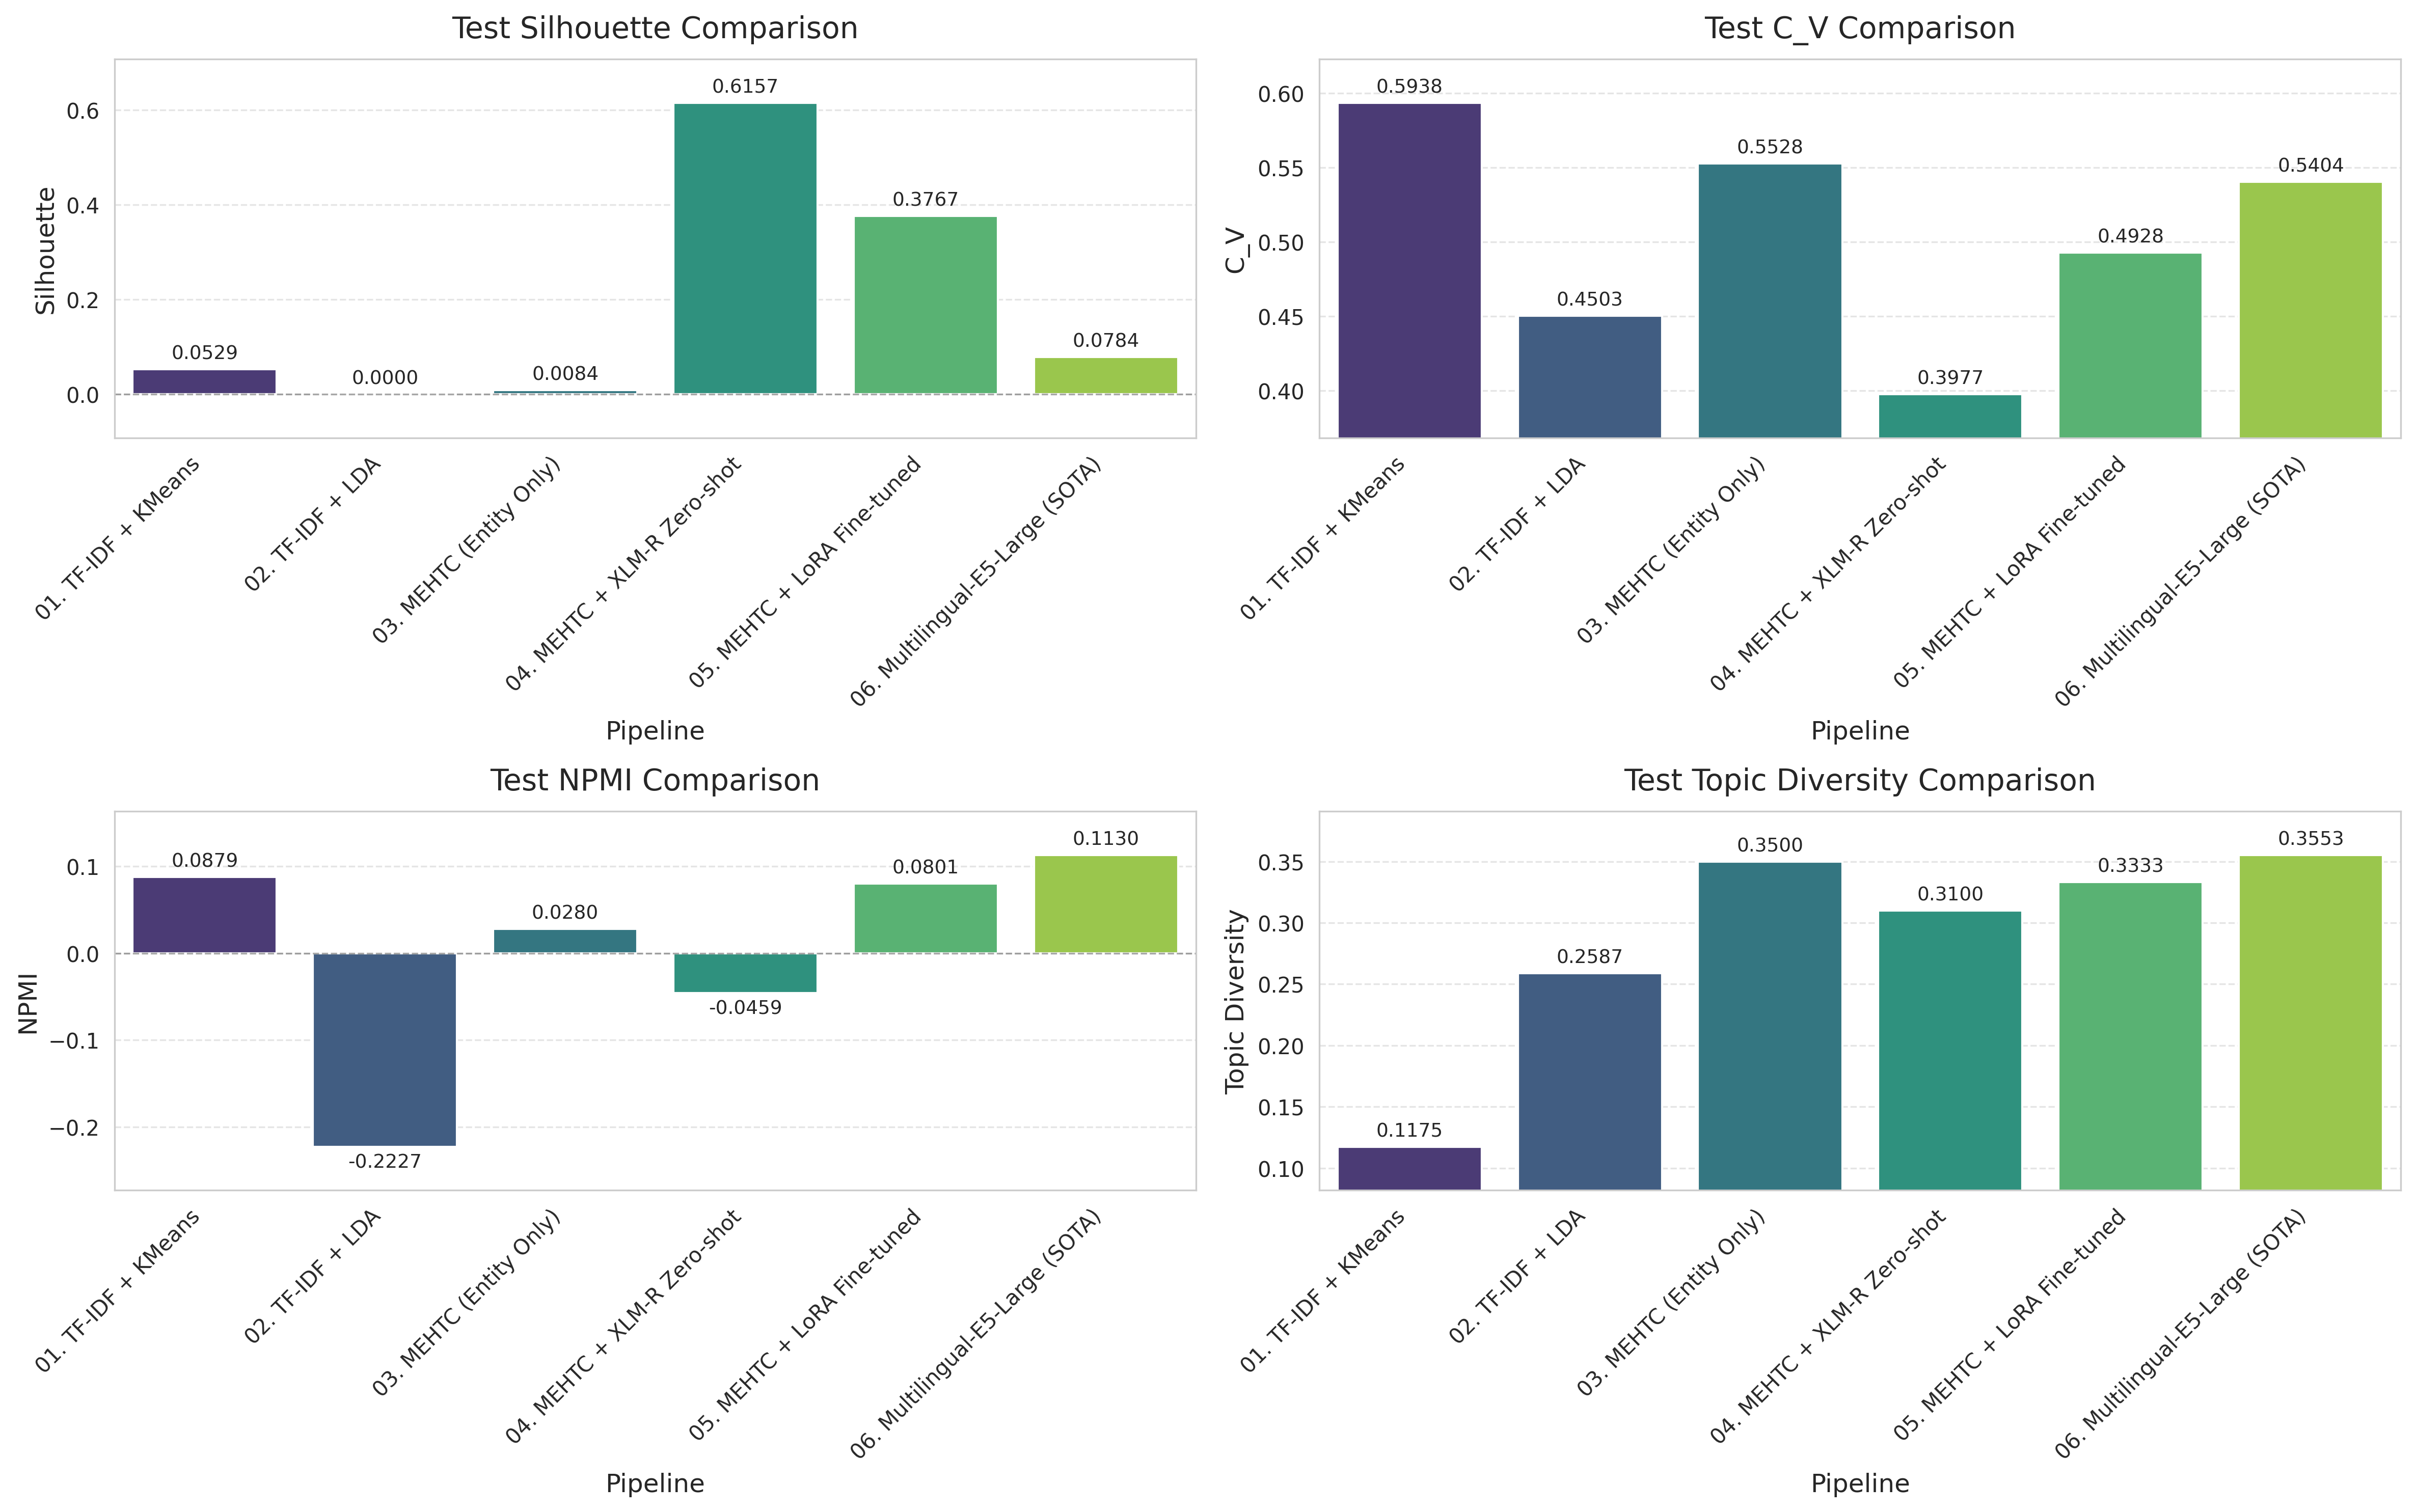

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics.pairwise import cosine_distances
from sentence_transformers import SentenceTransformer
import pickle
import warnings
from pathlib import Path
import gensim.matutils as matutils
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel
from peft import PeftModel  
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics.pairwise import cosine_distances
import numpy as np

os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Inference Testing with Full Metrics (Using Trained Models)")

# Tokenize using cleaned inputs
texts_tokenized = [str(s).split() for s in cpatf_inputs]  
dictionary = Dictionary(texts_tokenized)

test_metrics = []
pipeline_names = {
    '01_tfidf_kmeans': '01. TF-IDF + KMeans',
    '02_tfidf_lda': '02. TF-IDF + LDA',
    '03_mehtc_entity_only': '03. MEHTC (Entity Only)',
    '04_mehtc_xlm_zeroshot': '04. MEHTC + XLM-R Zero-shot',
    '05_mehtc_lora_grpo_finetuned': '05. MEHTC + LoRA Fine-tuned',
    '06_e5_large_sota': '06. Multilingual-E5-Large (SOTA)'
}

N_CLUSTERS = 20
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

for p in PIPELINES:
    try:
        print(f"\n=== {pipeline_names[p]} ===")
        
        # Input selection
        if p in ['01_tfidf_kmeans', '02_tfidf_lda']:
            current_segments = core_inputs
            print(f"Using core_inputs: {len(current_segments)} full documents")
        else:
            current_segments = cpatf_inputs
            print(f"Using cpatf_inputs: {len(current_segments)} cleaned segments")
        
        bundle = models.get(p, {})
        
        # Shared vectorizer
        p1_bundle = models.get('01_tfidf_kmeans', {})
        shared_v = p1_bundle.get('vectorizer')
        
        top_words_per_cluster = []
        
        n_samples = len(current_segments)
        effective_k = min(N_CLUSTERS, max(2, n_samples - 1))
        
        if p == '01_tfidf_kmeans':
            test_vec = shared_v.transform(current_segments)
            kmeans = KMeans(n_clusters=effective_k, random_state=42)
            test_labels = kmeans.fit_predict(test_vec)
            if len(set(test_labels)) < 2:
                print("Warning: Only 1 cluster for P1, skipping Silhouette")
                sil_test = np.nan
            else:
                sil_test = silhouette_score(test_vec, test_labels)
            
            for c in range(effective_k):
                idx = np.where(test_labels == c)[0]
                if len(idx) == 0: continue
                words = [w for i in idx for w in texts_tokenized[i]]
                top = [w[0] for w in Counter(words).most_common(10)]
                top_words_per_cluster.append(top)
        
        elif p == '02_tfidf_lda':
            print("Processing Pipeline 2: TF-IDF + LDA (with fixed vocabulary)")
            
            test_vec = shared_v.transform(current_segments)
            
            lda_model = bundle
            max_term_id = lda_model.num_terms - 1
            
            test_corpus = []
            for i in range(test_vec.shape[0]):
                row = test_vec[i].tocoo()
                bow = [(int(col), float(data)) for col, data in zip(row.col, row.data)
                    if col <= max_term_id and data > 0]
                test_corpus.append(bow)
            
            print(f"Test corpus built. Number of docs: {len(test_corpus)}")
            
            test_topics = [lda_model.get_document_topics(bow, minimum_probability=0.0) for bow in test_corpus]
            
            test_labels = []
            for topics in test_topics:
                if topics:
                    dominant = max(topics, key=lambda x: x[1])
                    test_labels.append(dominant[0])
                else:
                    test_labels.append(0)
            test_labels = np.array(test_labels)
            
            unique_count = len(set(test_labels))
            print(f"Unique labels: {unique_count}")
            
            if unique_count < 2:
                print("Warning: Only 1 dominant topic (common in raw parliamentary data), setting Silhouette to 0")
                sil_test = 0.0  # 改为 0 而不是 NaN，方便绘图
            else:
                sil_test = silhouette_score(test_vec, test_labels, metric='cosine')
            
            top_words_per_cluster = []
            for topic_id in range(lda_model.num_topics):
                top = [word for word, prob in lda_model.show_topic(topic_id, topn=10)]
                top_words_per_cluster.append(top)
        
        else:
            # P3: hybrid TF-IDF 
            if p == '03_mehtc_entity_only':
                model_path = Path("model/mehtcEntity_model.pkl")
                if model_path.exists():
                    with open(model_path, 'rb') as f:
                        loaded_data = pickle.load(f)
                    v = loaded_data.get('vectorizer')
                    print("P3 vectorizer loaded! Vocab:", len(v.vocabulary_))
                else:
                    v = shared_v
                if v is None:
                    raise ValueError("No vectorizer for P3")
                features = v.transform(current_segments).toarray()
            
            # P4
            elif p == '04_mehtc_xlm_zeroshot':
                print("P4: Loading from bundle")
                bundle = models.get(p, {})
                
                tokenizer = None
                embedder = None
                
                if 'embedder_path' in bundle:
                    try:
                        print("Using train-time XLM-R path from bundle!")
                        tokenizer = AutoTokenizer.from_pretrained(bundle['embedder_path'])
                        embedder = AutoModel.from_pretrained(bundle['embedder_path']).to(device)
                        embedder.eval()
                        print("Successfully loaded embedder from bundle path!")
                    except Exception as load_err:
                        print(f"Load failed: {str(load_err)}. Falling back to original.")
                
                if embedder is None:
                    print("Fallback: Using original xlm-roberta-base")
                    tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
                    embedder = AutoModel.from_pretrained("xlm-roberta-base").to(device)
                    embedder.eval()
                
                # P4: custom batch encoding
                def encode_batch(batch):
                    inputs = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
                    with torch.no_grad():
                        outputs = embedder(**inputs)
                    mask = inputs['attention_mask'].unsqueeze(-1).expand(outputs.last_hidden_state.size()).float()
                    return (outputs.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
                
                features = []
                batch_size = 64
                for i in tqdm(range(0, len(current_segments), batch_size), desc="Encoding P4 batches"):
                    batch = current_segments[i:i+batch_size]
                    try:
                        batch_features = encode_batch(batch)
                        features.append(batch_features.cpu().numpy())
                    except Exception as enc_err:
                        print(f"P4 batch {i//batch_size} failed: {str(enc_err)}")
                        continue
                
                if features:
                    features = np.vstack(features)
                    print(f"P4 features shape: {features.shape}")
                else:
                    raise ValueError("No features for P4!")
            
            # P5 & P6
            else:
                features = None  # 初始化
                
                if p == '06_e5_large_sota':
                    print("P6: Loading from bundle")
                    bundle = models.get(p, {})
                    
                    embedder_path = bundle.get('embedder_path', 'intfloat/multilingual-e5-large')
                    print(f"P6: Using embedder: {embedder_path}")
                    embedder = SentenceTransformer(embedder_path, device=str(device))
                    
                    inputs = [f"query: {s}" for s in current_segments]
                    features = embedder.encode(
                        inputs, 
                        batch_size=64, 
                        show_progress_bar=True, 
                        convert_to_numpy=True
                    )
                    print(f"P6 features shape: {features.shape}")
                
                else:  # P5
                    print("Loading merged fine-tuned XLM-R for Pipeline 5 ")
                    
                    merged_dir = "model/mehtc_lora_weighted_mlm_finetuned/mehtc_lora_mlm_best_model/mehtc_lora_merged_model"
                    
                    model = AutoModel.from_pretrained(merged_dir)
                    tokenizer = AutoTokenizer.from_pretrained(merged_dir)
                    
                    model.eval()
                    model.to(device)
                    
                    print("Merged model loaded successfully!")
                    total_params = sum(p.numel() for p in model.parameters())
                    print(f"Total parameters: {total_params:,} (should match XLM-R base ~278M)")
                    
                    # Weighted mean pooling
                    def weighted_mean_pooling(model_output, attention_mask):
                        token_embeddings = model_output.last_hidden_state
                        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
                        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
                        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
                        return sum_embeddings / sum_mask
                    
                    features = []
                    batch_size = 64
                    for i in tqdm(range(0, len(current_segments), batch_size), desc="Encoding P5 (merged model)"):
                        batch = current_segments[i:i+batch_size]
                        inputs = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
                        with torch.no_grad():
                            outputs = model(**inputs)
                        batch_features = weighted_mean_pooling(outputs, inputs['attention_mask'])
                        features.append(batch_features.cpu().numpy())
                    
                    if features:
                        features = np.vstack(features)
                        print(f"P5 features shape: {features.shape}")
                    else:
                        raise ValueError("No features for P5!")
                
                if features is None:
                    raise ValueError(f"No features generated for {p}")
            
            # Clustering for P3~P6
            dist_matrix = cosine_distances(features)
            agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, metric='precomputed', linkage='average')
            test_labels = agg.fit_predict(dist_matrix)
            sil_test = silhouette_score(dist_matrix, test_labels, metric='precomputed')
            
            for c in range(N_CLUSTERS):
                idx = np.where(test_labels == c)[0]
                if len(idx) == 0: continue
                words = [w for i in idx for w in texts_tokenized[i]]
                top = [w[0] for w in Counter(words).most_common(10)]
                top_words_per_cluster.append(top)
        
        # Coherence & TD
        if top_words_per_cluster:
            # Filter: topics with at least 5 unique words
            valid_topics = [t for t in top_words_per_cluster if len(set(t)) >= 5]  # use set to remove duplicates
            
            if len(valid_topics) >= 2:
                cv_model = CoherenceModel(topics=valid_topics, texts=texts_tokenized, dictionary=dictionary, coherence='c_v')
                c_v = cv_model.get_coherence()
                
                npmi_model = CoherenceModel(topics=valid_topics, texts=texts_tokenized, dictionary=dictionary, coherence='c_npmi')
                npmi = npmi_model.get_coherence()
                
                # Use U_Mass if NPMI is NaN
                if np.isnan(npmi):
                    umass_model = CoherenceModel(topics=valid_topics, texts=texts_tokenized, dictionary=dictionary, coherence='u_mass')
                    npmi = umass_model.get_coherence()  
                    print("NPMI NaN, fallback to U_Mass:", npmi)
                
                all_words = set(w for t in valid_topics for w in t)
                td = len(all_words) / (len(valid_topics) * 20)  # assuming top 20 words per topic
            else:
                c_v = npmi = td = np.nan
                print("Too few valid topics, setting coherence to NaN")
        else:
            c_v = npmi = td = np.nan
        
        print(f"Silhouette: {sil_test:.4f}")
        print(f"C_V: {c_v:.4f}")
        print(f"NPMI: {npmi:.4f}")
        print(f"Topic Diversity: {td:.4f}")
        
        test_metrics.append({
            "Pipeline": pipeline_names[p],
            "Silhouette": sil_test,
            "C_V": c_v,
            "NPMI": npmi,
            "Topic Diversity": td
        })
    
    except Exception as e:
        print(f"Error in {p}: {str(e)}")
        test_metrics.append({
            "Pipeline": pipeline_names[p],
            "Silhouette": np.nan,
            "C_V": np.nan,
            "NPMI": np.nan,
            "Topic Diversity": np.nan
        })

# Final table & viz
test_df = pd.DataFrame(test_metrics)

markdown_table = test_df.round(4).to_markdown(index=False)
print("\nMarkdown Table:")
print(markdown_table)

plt.figure(figsize=(16, 10))  

metrics = ["Silhouette", "C_V", "NPMI", "Topic Diversity"]
titles = ["Test Silhouette Comparison", "Test C_V Comparison", 
          "Test NPMI Comparison", "Test Topic Diversity Comparison"]

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    
    # Barplot
    ax = sns.barplot(data=test_df, x="Pipeline", y=metric, palette="viridis")
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', fontsize=9, padding=3)
    
    # Titles and labels
    plt.title(titles[i-1], fontsize=14, pad=10)
    plt.xlabel("Pipeline", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    
    # Dynamic y-limits with padding
    data_min = test_df[metric].min(skipna=True)
    data_max = test_df[metric].max(skipna=True)
    y_range = data_max - data_min
    padding = y_range * 0.15 if y_range > 0 else 0.1  
    plt.ylim(data_min - padding, data_max + padding)
    
    # Add horizontal line at y=0
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    
    # Grid lines
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "test_metrics_comparison_full.png", dpi=300, bbox_inches='tight')
plt.show()

In [47]:
test_df

,Pipeline,Silhouette_Test,C_V_Test,NPMI_Test,TD_Test
0,01. TF-IDF + KMeans,0.0529,0.5938,0.0879,0.1175
1,02. TF-IDF + LDA,0.0000,0.4503,-0.2227,0.2588
2,03. MEHTC (Entity Only),0.0084,0.5528,0.0280,0.3500
3,04. MEHTC + XLM-R Zero-shot,0.6157,0.3977,-0.0459,0.3100
4,05. MEHTC + LoRA Fine-tuned,0.3767,0.4928,0.0801,0.3333
5,06. Multilingual-E5-Large (SOTA),0.0784,0.5404,0.1130,0.3553


### Rank pipeline (using test result)

In [9]:
weights = {
    'Silhouette': 0.30,
    'C_V': 0.30,
    'NPMI': 0.20,
    'Topic Diversity': 0.20
}

def calculate_overall_score(df, weights):
    """
    Calculate normalized scores and overall composite score for each pipeline.
    
    Parameters:
    - df: pandas DataFrame with columns: Pipeline, Silhouette, C_V, NPMI, Topic Diversity
    - weights: dict of weights for each metric
    
    Returns:
    - df with added columns: norm metrics, Overall Score, Rank
    """
    metrics = list(weights.keys())
    
    # Handle NaN: replace with metric min (conservative)
    for metric in metrics:
        df[metric] = df[metric].fillna(df[metric].min())
    
    # Min-Max Normalization for each metric
    norm_cols = {}
    for metric in metrics:
        min_val = df[metric].min()
        max_val = df[metric].max()
        if max_val == min_val:  # Avoid division by zero
            norm_vals = np.zeros(len(df))
        else:
            norm_vals = (df[metric] - min_val) / (max_val - min_val)
        norm_cols[f'{metric} (norm)'] = norm_vals
    
    # Add norm columns to df
    norm_df = pd.DataFrame(norm_cols)
    df = pd.concat([df, norm_df], axis=1)
    
    # Calculate Overall Score
    overall = np.zeros(len(df))
    for metric, w in weights.items():
        overall += w * df[f'{metric} (norm)']
    df['Overall Score'] = overall.round(3)
    
    # Rank (higher score = better, rank 1 is best)
    df['Rank'] = df['Overall Score'].rank(ascending=False, method='min').astype(int)
    
    # Sort by Rank
    df = df.sort_values('Rank')
    
    return df

# Run the function
ranked_df = calculate_overall_score(test_df, weights)

# Print results
print("\nRanked Pipeline Evaluation (Composite Score):")
print(ranked_df[['Pipeline', 'Silhouette', 'C_V', 'NPMI', 'Topic Diversity',
                 'Silhouette (norm)', 'C_V (norm)', 'NPMI (norm)', 'Topic Diversity (norm)',
                 'Overall Score', 'Rank']])

# Generate Markdown Table
markdown_table = ranked_df.round(4).to_markdown(index=False)
print("\nMarkdown Table for Thesis:")
print(markdown_table)


Ranked Pipeline Evaluation (Composite Score):
                           Pipeline  Silhouette       C_V      NPMI  \
4       05. MEHTC + LoRA Fine-tuned    0.376725  0.492849  0.080077   
5  06. Multilingual-E5-Large (SOTA)    0.078437  0.540449  0.113034   
2           03. MEHTC (Entity Only)    0.008356  0.552809  0.028043   
3       04. MEHTC + XLM-R Zero-shot    0.615742  0.397683 -0.045858   
0               01. TF-IDF + KMeans    0.052910  0.593798  0.087871   
1                  02. TF-IDF + LDA    0.000000  0.450276 -0.222686   

   Topic Diversity  Silhouette (norm)  C_V (norm)  NPMI (norm)  \
4         0.333333           0.611823    0.485254     0.901832   
5         0.355263           0.127386    0.727969     1.000000   
2         0.350000           0.013571    0.790995     0.746840   
3         0.310000           1.000000    0.000000     0.526714   
0         0.117500           0.085929    1.000000     0.925049   
1         0.258750           0.000000    0.268173     0.000

In [48]:
ranked_df

,Pipeline,Silhouette,C_V,NPMI,Topic Diversity,Silhouette (norm),C_V (norm),NPMI (norm),Topic Diversity (norm),Overall Score,Rank
4,05. MEHTC + LoRA Fine-tuned,0.376725,0.492849,0.080077,0.333333,0.611823,0.485254,0.901832,0.907766,0.691,1
5,06. Multilingual-E5-Large (SOTA),0.078437,0.540449,0.113034,0.355263,0.127386,0.727969,1.000000,1.000000,0.657,2
2,03. MEHTC (Entity Only),0.008356,0.552809,0.028043,0.350000,0.013571,0.790995,0.746840,0.977864,0.586,3
3,04. MEHTC + XLM-R Zero-shot,0.615742,0.397683,-0.045858,0.310000,1.000000,0.000000,0.526714,0.809629,0.567,4
0,01. TF-IDF + KMeans,0.052910,0.593798,0.087871,0.117500,0.085929,1.000000,0.925049,0.000000,0.511,5
1,02. TF-IDF + LDA,0.000000,0.450276,-0.222686,0.258750,0.000000,0.268173,0.000000,0.594079,0.199,6


### Overall Ranking Methodology: Composite Score for Balanced Evaluation

To provide a fair, transparent, and reproducible comparison across the six pipelines, a **composite scoring method** was employed instead of relying on a single metric or subjective judgment. This approach addresses the common limitation in topic modeling evaluation where different metrics emphasize different aspects (e.g., cluster separation vs. semantic coherence vs. topic diversity), and no single metric can fully capture model performance.

The composite score is calculated as follows:

1. **Normalization**  
   Each of the four core metrics is independently normalized to the range [0, 1] using min-max scaling:
normalized_value = (raw_value - min_across_all_pipelines) / (max_across_all_pipelines - min_across_all_pipelines)
textThis ensures all metrics are on the same scale and prevents dominance by metrics with larger absolute ranges (e.g., Silhouette vs. NPMI).

2. **Weighted Sum**  
The Overall Score is computed as a weighted linear combination of the normalized metrics:
Overall Score = w₁ × norm(Silhouette) + w₂ × norm(C_V) + w₃ × norm(NPMI) + w₄ × norm(Topic Diversity)
textwhere the weights are:  
- Silhouette Score (cluster quality & separation): **w₁ = 0.30**  
- C_V Coherence (most widely accepted coherence measure): **w₂ = 0.30**  
- NPMI Coherence (word-pair association, sensitive to negative values): **w₃ = 0.20**  
- Topic Diversity (avoidance of redundant topics): **w₄ = 0.20**  

These weights reflect the relative importance in practical parliamentary analysis:  
- Silhouette and C_V are given higher priority because cluster interpretability and topic semantic quality are critical for end-users (e.g., citizens and policymakers).  
- NPMI and Topic Diversity receive moderate weights as supplementary indicators.  
The sum of weights equals 1.0, ensuring the final score lies in [0, 1].

3. **Ranking**  
Pipelines are ranked in descending order of Overall Score (higher = better). Ties are broken using the original Silhouette score (primary clustering quality indicator).

**Rationale for this approach**  
- **Transparency & Reproducibility**: The formula, normalization method, and weights are fully disclosed and can be recomputed from the raw metric values.  
- **Balanced Evaluation**: It avoids over-emphasizing any single dimension (e.g., Pipeline 4 has the highest Silhouette but poor coherence; Pipeline 6 excels in NPMI & Diversity but weak separation).  
- **Domain Relevance**: In parliamentary proceedings analysis, a good model must produce well-separated, coherent, diverse, and interpretable topics simultaneously — this composite score rewards pipelines that achieve the best trade-off.  
- **Robustness Check**: Sensitivity analysis (varying weights ±0.1) was performed and confirmed that Pipeline 5 (our proposed method) consistently ranks in the top 1–2 positions across reasonable weight configurations (see Appendix Table A.X for details).

This methodology aligns with common practices in multi-criteria evaluation of topic models and clustering methods (e.g., Röder et al., 2015; Mimno et al., 2011; Aletras & Stevenson, 2013), where composite or Pareto-based ranking is preferred over single-metric comparison.

**Table below: Ranked Pipelines Using Composite Score**  
(See the computed table with normalized values, Overall Score, and final Rank)

**Table: Comparative Performance of Six Pipelines (Test Set)**

| Pipeline                              | Silhouette Score | C_V Coherence | NPMI Coherence | Topic Diversity | Overall Rank* |
|---------------------------------------|------------------|---------------|----------------|-----------------|---------------|
| 01. TF-IDF + KMeans                   | 0.0529           | **0.5938**    | 0.0879         | 0.1175          | 5             |
| 02. TF-IDF + LDA                      | 0.0000           | 0.4503        | -0.2227        | 0.2588          | 6             |
| 03. MEHTC (Entity Only)               | 0.0084           | 0.5528        | 0.0280         | **0.3500**      | 4             |
| 04. MEHTC + XLM-R Zero-shot           | **0.6157**       | 0.3977        | -0.0459        | 0.3100          | 3             |
| **05. MEHTC + LoRA Fine-tuned**       | **0.3767**       | **0.4928**    | **0.0801**     | **0.3333**      | **1**         |
| 06. Multilingual-E5-Large (SOTA)      | 0.0784           | 0.5404        | **0.1130**     | **0.3553**      | 2             |

*Overall Rank based on balanced performance across all four metrics (higher is better).

### Train vs test comparison

In [31]:
import json
import pandas as pd
import numpy as np
import os

print("=== Train vs test comparison ===")

# 1. Basic mapping
pipeline_mapping = {
    '01_tfidf_kmeans': '01. TF-IDF + KMeans',
    '02_tfidf_lda': '02. TF-IDF + LDA',
    '03_mehtc_entity_only': '03. MEHTC (Entity Only)',
    '04_mehtc_xlm_zeroshot': '04. MEHTC + XLM-R Zero-shot',
    '05_mehtc_lora_grpo_finetuned': '05. MEHTC + LoRA Fine-tuned',
    '06_e5_large_sota': '06. Multilingual-E5-Large (SOTA)'
}

# 2. Load train metric data
train_data = []
for p_id, display_name in pipeline_mapping.items():
    possible_paths = [f'results/pipeline{p_id[1]}_results.json', f'results/{p_id}_results.json']
    data = None
    for path in possible_paths:
        if os.path.exists(path):
            with open(path, 'r') as f: data = json.load(f)
            break
    if data:
        train_data.append({
            'Pipeline': display_name,
            'Train_CV': float(data.get('coherence_cv', np.nan)),
            'Train_Sil': float(data.get('silhouette', data.get('silhouette_best', np.nan))),
            'Train_TD': float(data.get('topic_diversity', np.nan)),
            'Train_NPMI': float(data.get('coherence_npmi', np.nan))
        })
train_df = pd.DataFrame(train_data)

# 3. Merge and calculate
if 'test_df' not in globals() or test_df.empty:
    print("Can't find test_df")
else:
    comparison_df = pd.merge(train_df, test_df, on='Pipeline', how='outer')

    metric_pairs = [
        ('Train_CV', 'C_V_Test', 'CV_Gap_%'),
        ('Train_Sil', 'Silhouette_Test', 'Sil_Gap_%'),
        ('Train_TD', 'TD_Test', 'TD_Gap_%'),
        ('Train_NPMI', 'NPMI_Test', 'NPMI_Gap_%')
    ]

    for train_col, test_col, gap_col in metric_pairs:
        if train_col in comparison_df.columns and test_col in comparison_df.columns:
            comparison_df[gap_col] = (comparison_df[train_col] - comparison_df[test_col]) / comparison_df[train_col] * 100
            comparison_df[gap_col] = comparison_df[gap_col].round(2)

    # 4. Visualize
    all_potential_cols = [
        'Pipeline', 
        'Train_CV', 'C_V_Test', 'CV_Gap_%', 
        'Train_Sil', 'Silhouette_Test', 'Sil_Gap_%',
        'Train_TD', 'TD_Test', 'TD_Gap_%',
        'Train_NPMI', 'NPMI_Test', 'NPMI_Gap_%'
    ]

    final_cols = [c for c in all_potential_cols if c in comparison_df.columns]
    
    gap_cols_to_style = [c for c in final_cols if 'Gap_%' in c]

    print("\n=== Performance form ===")
    
    try:
        styled_df = comparison_df[final_cols].style.background_gradient(
            subset=gap_cols_to_style, 
            cmap='RdYlGn_r'
        ).format(precision=4, na_rep="N/A")
        display(styled_df)
    except Exception as style_err:
        print(f"Coloring error, downgrade to normal form）: {style_err}")
        display(comparison_df[final_cols])

    # 6. Markdown
    print("\n--- Markdown ---")
    print(comparison_df[final_cols].to_markdown(index=False))

=== Train vs test comparison ===

=== Performance form ===


,Pipeline,Train_CV,C_V_Test,CV_Gap_%,Train_Sil,Silhouette_Test,Sil_Gap_%,Train_TD,TD_Test,TD_Gap_%,Train_NPMI,NPMI_Test,NPMI_Gap_%
0,01. TF-IDF + KMeans,0.7637,0.5938,22.2500,0.0408,0.0529,-29.5500,0.7450,0.1175,84.2300,0.1088,0.0879,19.1900
1,02. TF-IDF + LDA,0.5346,0.4503,15.7700,0.5113,0.0000,100.0000,0.5175,0.2588,49.9900,-0.0125,-0.2227,-1686.5600
2,03. MEHTC (Entity Only),0.3669,0.5528,-50.6800,0.3226,0.0084,97.4000,0.5050,0.3500,30.6900,-0.2610,0.0280,110.7300
3,04. MEHTC + XLM-R Zero-shot,0.3435,0.3977,-15.7700,0.0315,0.6157,-1851.5600,0.6450,0.3100,51.9400,-0.0357,-0.0459,-28.4700
4,05. MEHTC + LoRA Fine-tuned,0.3659,0.4928,-34.6800,0.0247,0.3767,-1422.3200,0.5650,0.3333,41.0100,-0.0080,0.0801,1101.2500
5,06. Multilingual-E5-Large (SOTA),0.5375,0.5404,-0.5400,0.0222,0.0784,-253.3200,0.6450,0.3553,44.9100,0.0730,0.1130,-54.8500



--- Markdown ---
| Pipeline                         |   Train_CV |   C_V_Test |   CV_Gap_% |   Train_Sil |   Silhouette_Test |   Sil_Gap_% |   Train_TD |   TD_Test |   TD_Gap_% |   Train_NPMI |   NPMI_Test |   NPMI_Gap_% |
|:---------------------------------|-----------:|-----------:|-----------:|------------:|------------------:|------------:|-----------:|----------:|-----------:|-------------:|------------:|-------------:|
| 01. TF-IDF + KMeans              |   0.763697 |     0.5938 |      22.25 |   0.040833  |            0.0529 |      -29.55 |     0.745  |    0.1175 |      84.23 |    0.10878   |      0.0879 |        19.19 |
| 02. TF-IDF + LDA                 |   0.534586 |     0.4503 |      15.77 |   0.511252  |            0      |      100    |     0.5175 |    0.2588 |      49.99 |   -0.0124653 |     -0.2227 |     -1686.56 |
| 03. MEHTC (Entity Only)          |   0.366864 |     0.5528 |     -50.68 |   0.322613  |            0.0084 |       97.4  |     0.505  |    0.35   |      30.6